Para modificar a nível de código: atualmente tem muitos smells, codigo repetido, funções bagunçadas. Não é urgente mas seria legal refatorar

## Imports e carregamento

In [1]:
#!pip install kagglehub

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "arjunbhasin2013/ccdata",
  "CC GENERAL.csv",
)

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


| Coluna                           | Descrição                                                                                  | Tipo      |
|----------------------------------|--------------------------------------------------------------------------------------------|-----------|
| CUST_ID                          | Identificação do titular do cartão de crédito                                              | Nominal   |
| BALANCE                          | Saldo disponível na conta para realizar compras                                            | Contínua  |
| BALANCE_FREQUENCY                | Frequência de atualização do saldo (score de 0 a 1)                                        | Contínua  |
| PURCHASES                        | Valor total de compras realizadas na conta                                                 | Contínua  |
| ONEOFF_PURCHASES                 | Valor máximo de compra realizada de uma só vez                                             | Contínua  |
| INSTALLMENTS_PURCHASES           | Valor total de compras realizadas em parcelas                                              | Contínua  |
| CASH_ADVANCE                     | Valor de adiantamento em dinheiro solicitado pelo usuário                                  | Contínua  |
| PURCHASES_FREQUENCY              | Frequência com que compras são realizadas (score de 0 a 1)                                 | Contínua  |
| ONEOFF_PURCHASES_FREQUENCY       | Frequência de compras realizadas de uma só vez (score de 0 a 1)                            | Contínua  |
| PURCHASES_INSTALLMENTS_FREQUENCY | Frequência de compras realizadas em parcelas (score de 0 a 1)                              | Contínua  |
| CASH_ADVANCE_FREQUENCY           | Frequência com que o adiantamento em dinheiro é utilizado                                  | Contínua  |
| CASH_ADVANCE_TRX                 | Número de transações realizadas com adiantamento em dinheiro                               | Discreta  |
| PURCHASES_TRX                    | Número de transações de compra realizadas                                                  | Discreta  |
| CREDIT_LIMIT                     | Limite do cartão de crédito do usuário                                                     | Contínua  |
| PAYMENTS                         | Valor total de pagamentos realizados pelo usuário                                          | Contínua  |
| MINIMUM_PAYMENTS                 | Valor mínimo de pagamentos realizados pelo usuário                                         | Contínua  |
| PRC_FULL_PAYMENT                 | Percentual de pagamento total realizado pelo usuário                                       | Contínua  |
| TENURE                           | Tempo de uso do serviço do cartão de crédito (em meses)                                    | Discreta  |

## Pre-processamento e Análise exploratória

Expandir a exploração. Focar em encontrar inconsistencias no dataset, mas fazer alguns gráficos interessantes também

In [4]:
df.drop(columns=["CUST_ID"], inplace=True)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [7]:
missing_values_= df.isnull().sum().sort_values(ascending=False).head()
columns_with_missing_values = missing_values_[missing_values_ > 0].index

In [8]:
(df.isnull().sum().sort_values(ascending=False).head() / df.shape[0]) * 100

MINIMUM_PAYMENTS          3.497207
CREDIT_LIMIT              0.011173
BALANCE                   0.000000
CASH_ADVANCE_FREQUENCY    0.000000
PRC_FULL_PAYMENT          0.000000
dtype: float64

In [9]:
# Min pagamentos nulo, mas pagamentos > 0. Falha no sistema.
df[(df['MINIMUM_PAYMENTS'].isnull()) & (df['PAYMENTS']>0)].shape[0]

73

In [10]:
df[df['CREDIT_LIMIT'].isnull()]

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


In [11]:
df['CREDIT_LIMIT'].median()

3000.0

In [12]:
df = df.dropna(subset=['CREDIT_LIMIT'])

In [13]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=77)

imputer = SimpleImputer(strategy="median")
pipeline = Pipeline(steps=[("imputer", imputer)])
pipeline.fit(X_train[columns_with_missing_values])

X_train[columns_with_missing_values] = pipeline.transform(X_train[columns_with_missing_values])
X_test[columns_with_missing_values] = pipeline.transform(X_test[columns_with_missing_values])

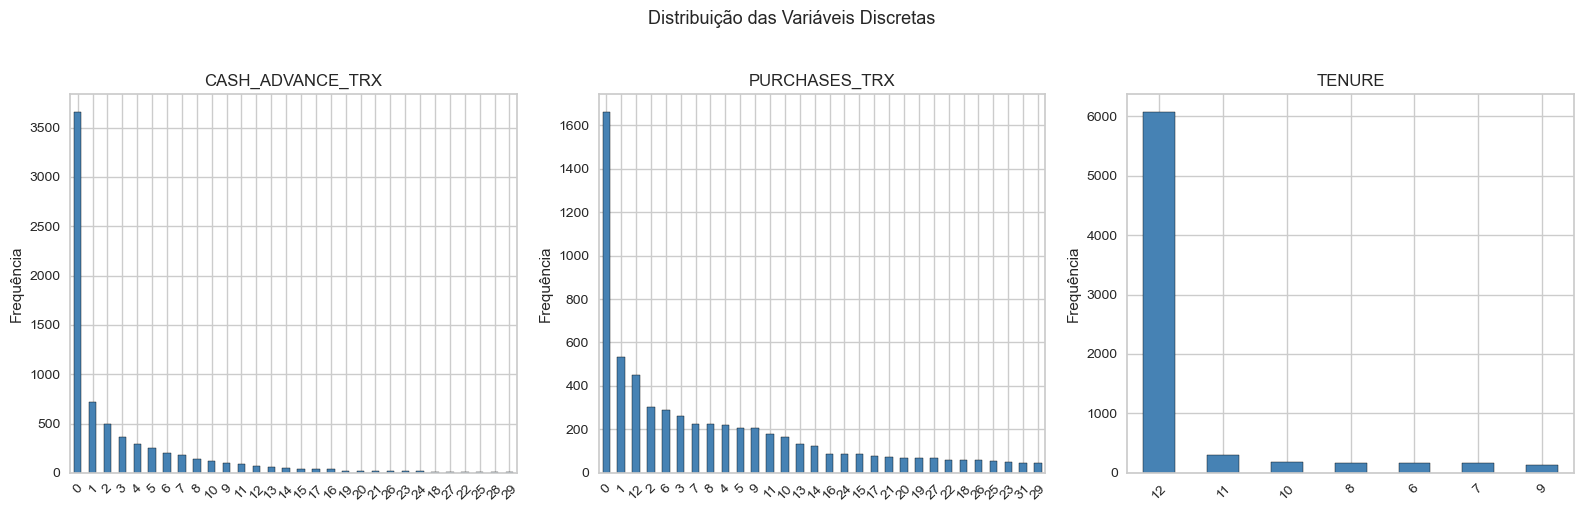

In [14]:
discrete_cols = ['CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'TENURE']

fig, axes = plt.subplots(1, len(discrete_cols), figsize=(16, 5))

for ax, col in zip(axes, discrete_cols):
    X_train[col].value_counts().sort_values(ascending=False).head(30).plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequência")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Distribuição das Variáveis Discretas", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

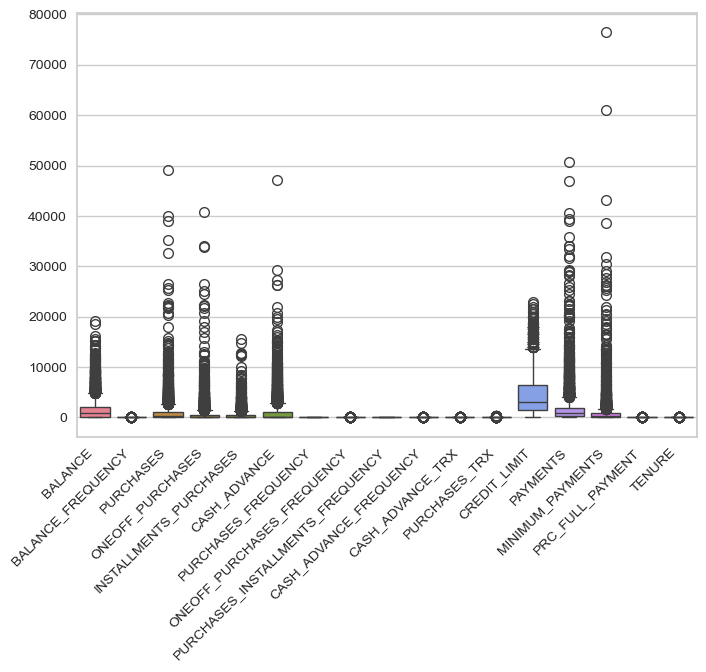

In [15]:
sns.boxplot(data=X_train)
plt.xticks(rotation=45, ha="right")
plt.show()

## Análise Visual com Dois Atributos

buscar por atributos melhores dos que eu selecionei, e identificar a lógica deles para a regra de negócio

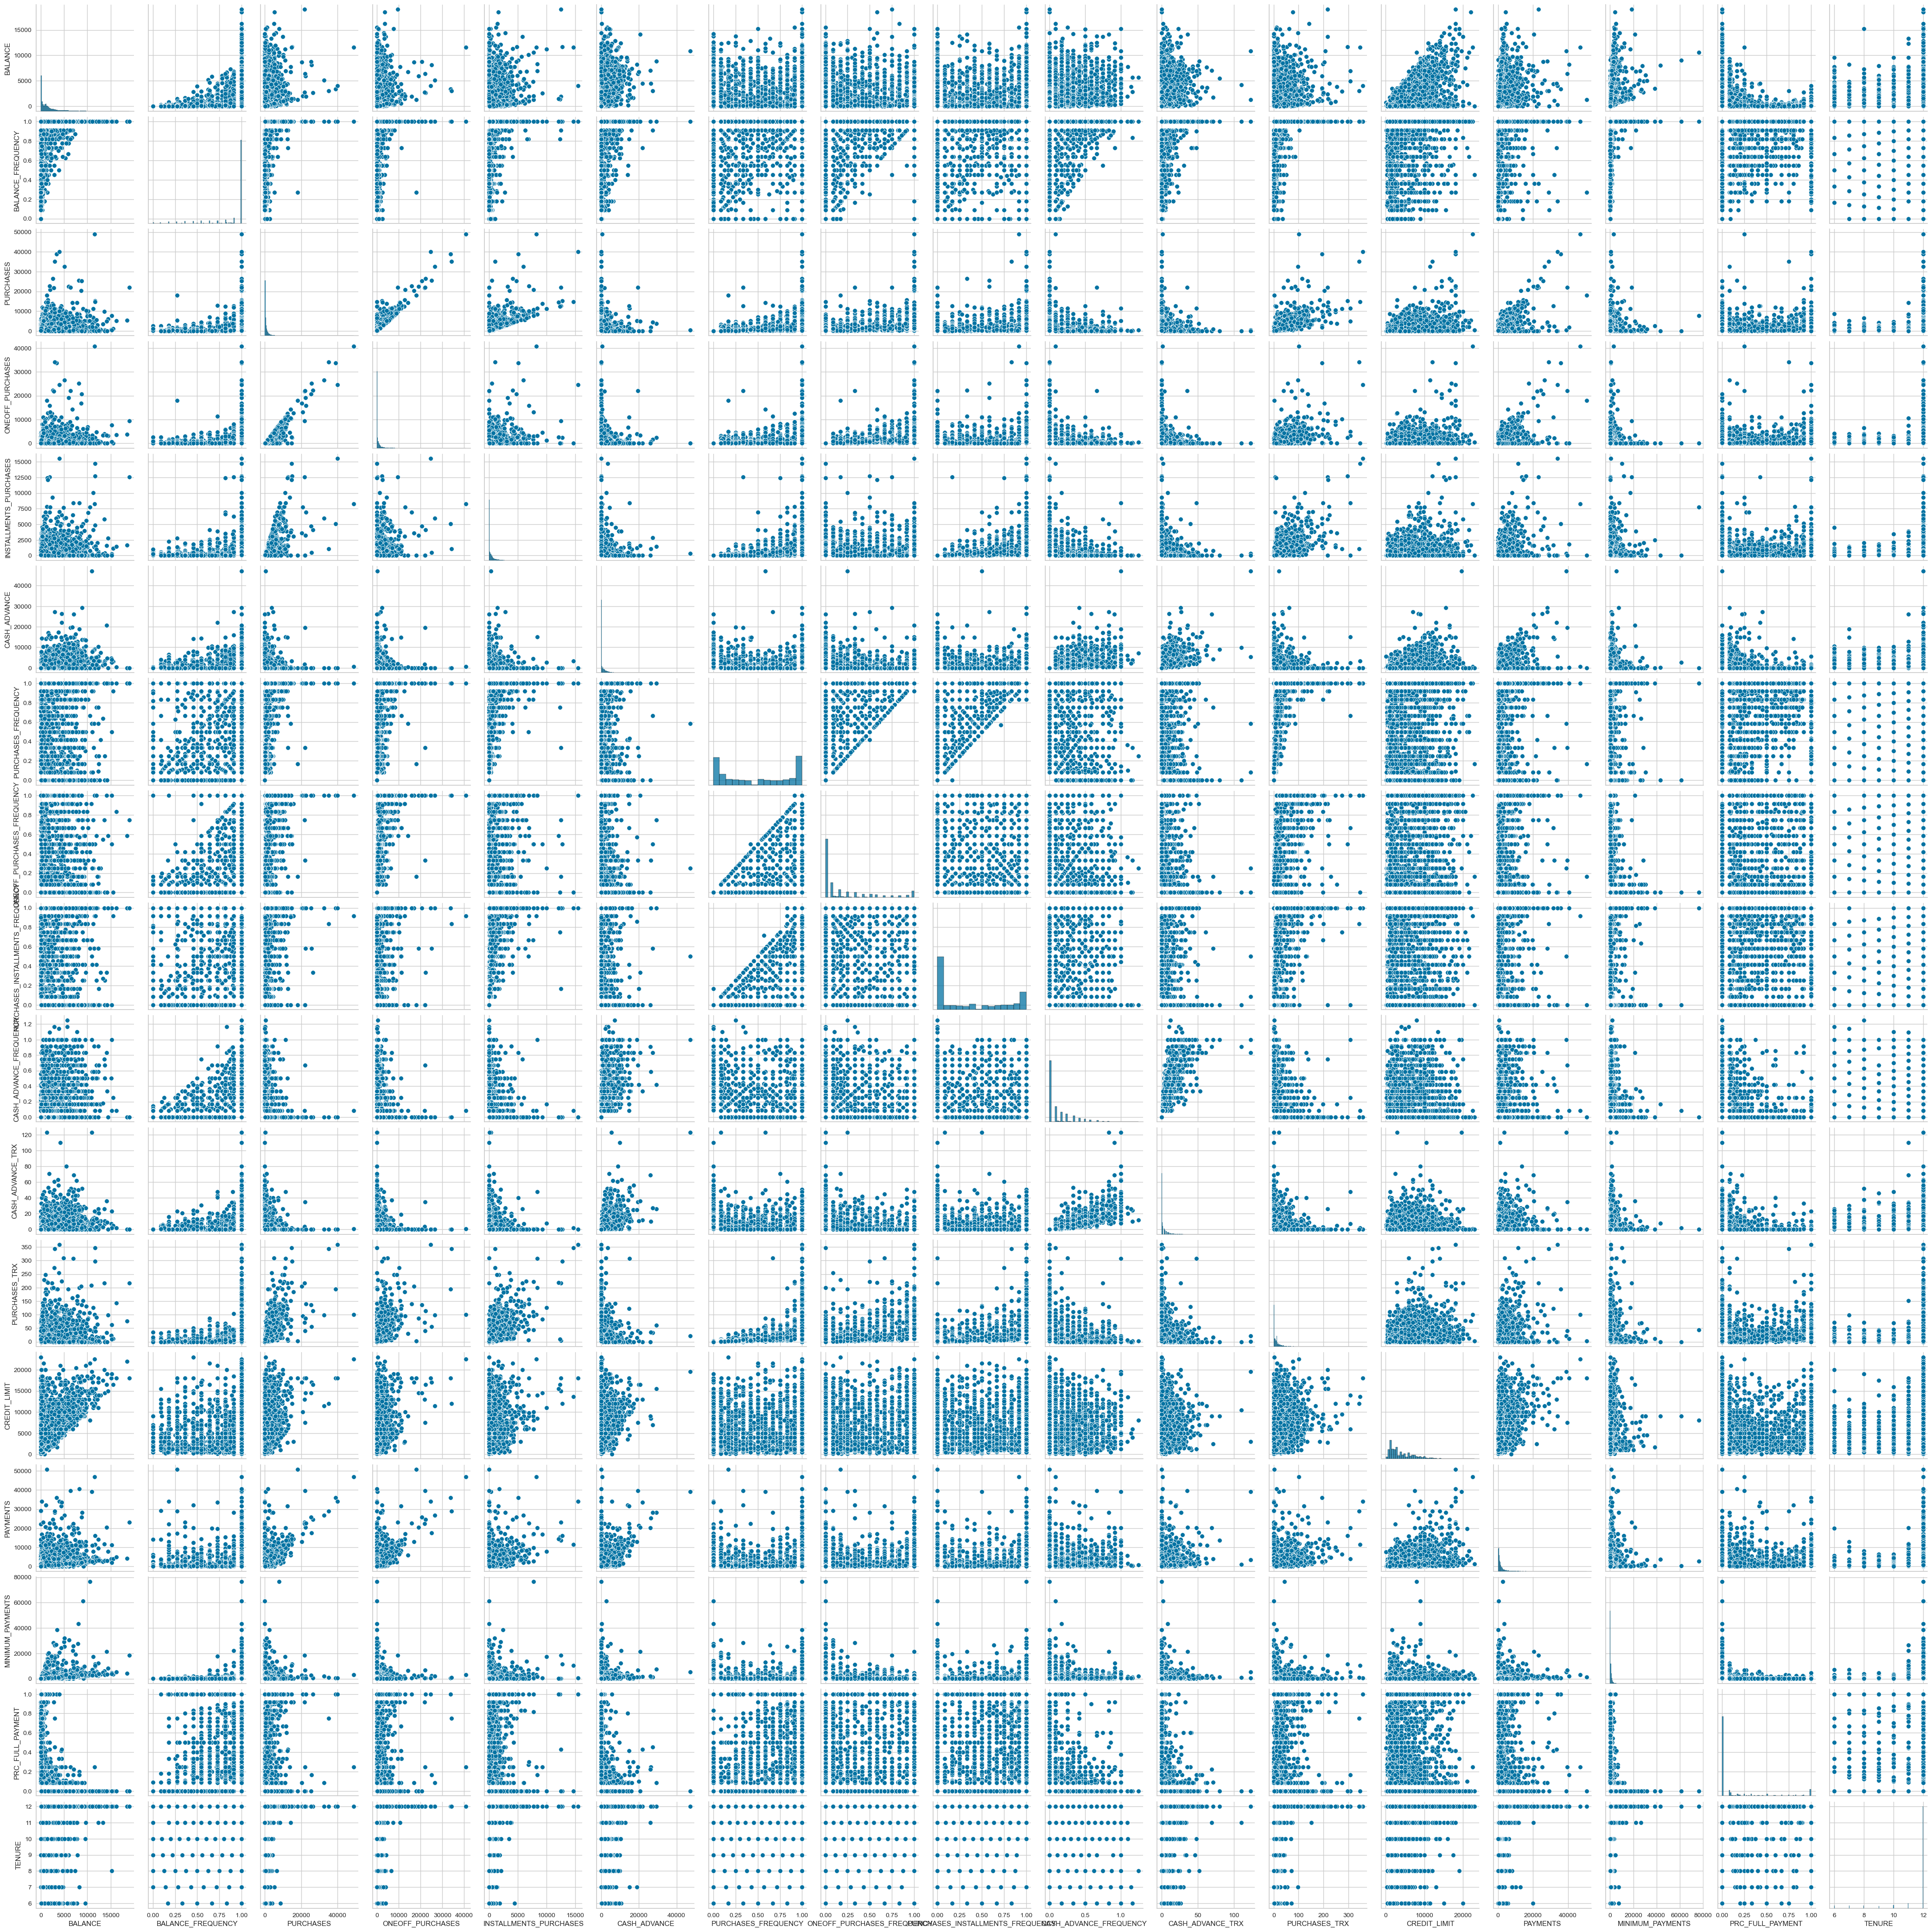

In [16]:
sns.pairplot(X_train)

gráficos de densidade pois imaginei que facilitaria a identificação de clusters

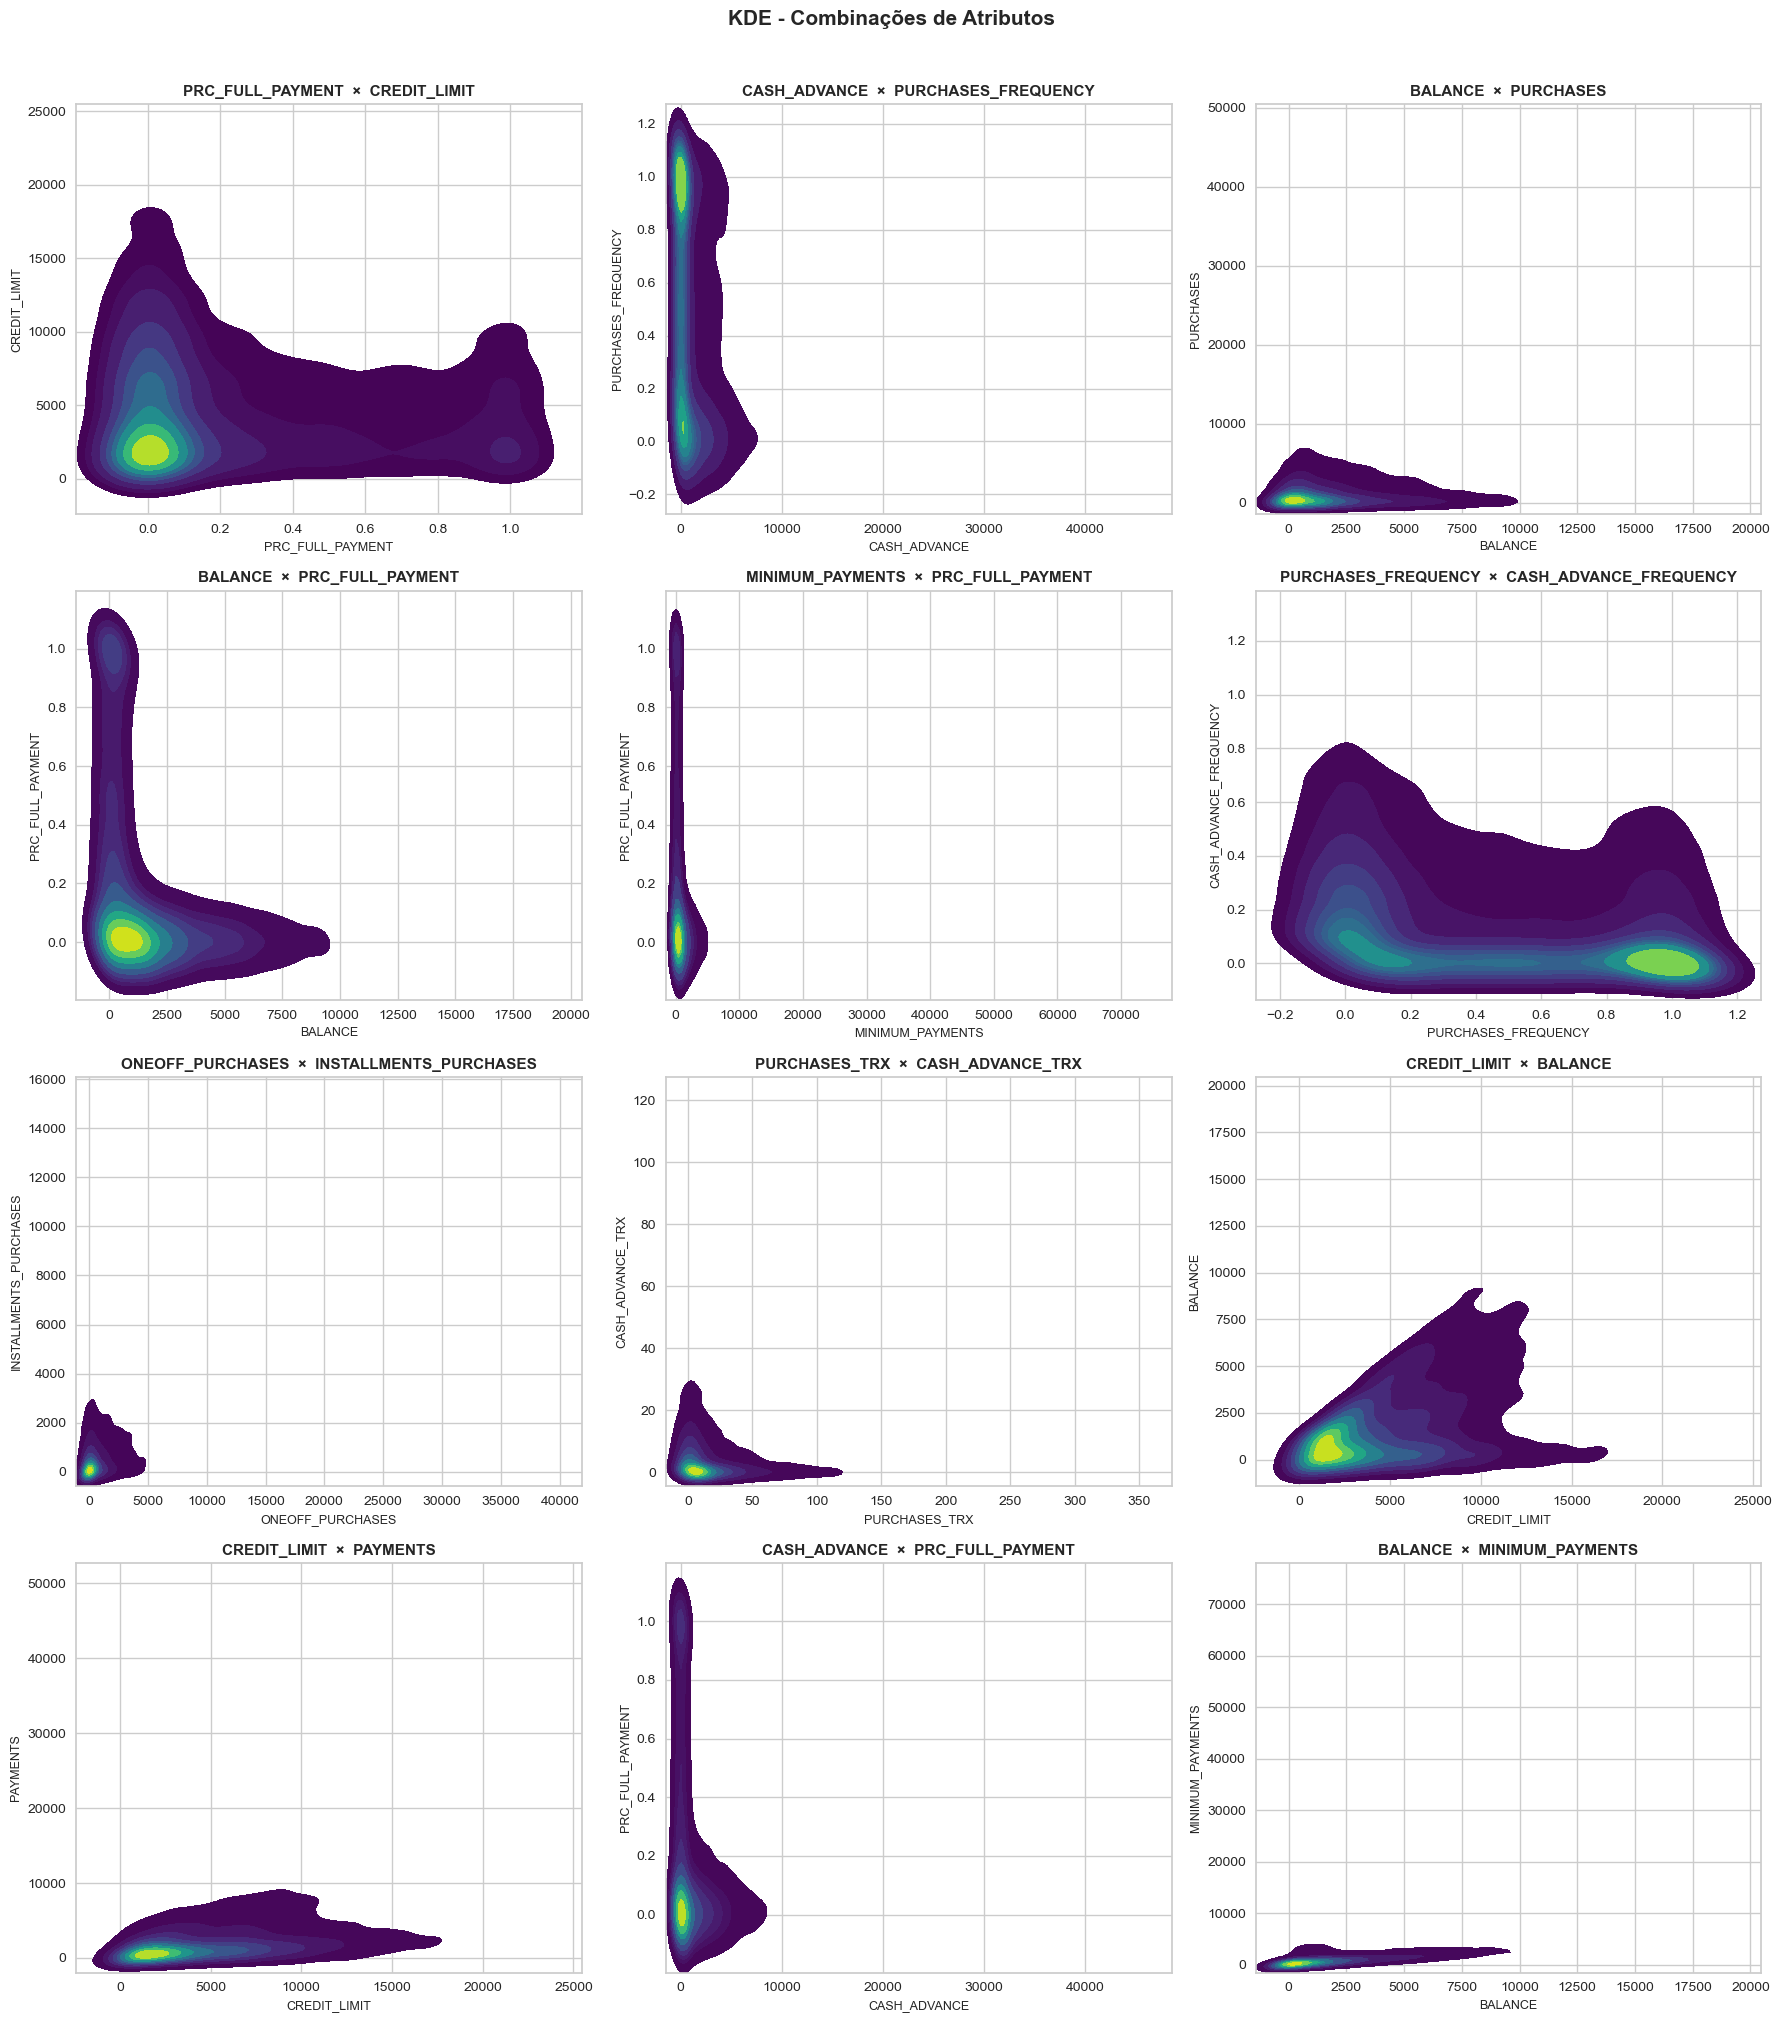

In [17]:
pairs = [  # Melhores candidatos que encontrei
    ("PRC_FULL_PAYMENT", "CREDIT_LIMIT"),
    ("CASH_ADVANCE", "PURCHASES_FREQUENCY"),
    ("BALANCE", "PURCHASES"),
    ("BALANCE", "PRC_FULL_PAYMENT"),
    ("MINIMUM_PAYMENTS", "PRC_FULL_PAYMENT"),
    ("PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY"),
    ("ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES"),
    ("PURCHASES_TRX", "CASH_ADVANCE_TRX"),
    ("CREDIT_LIMIT", "BALANCE"),
    ("CREDIT_LIMIT", "PAYMENTS"),
    ("CASH_ADVANCE", "PRC_FULL_PAYMENT"),
    ("BALANCE", "MINIMUM_PAYMENTS"),
]

discrete_cols = 3
rows = len(pairs) // discrete_cols + (1 if len(pairs) % discrete_cols else 0)

fig, axes = plt.subplots(rows, discrete_cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(pairs):
    sns.kdeplot(data=X_train, x=x_col, y=y_col, cmap="viridis", fill=True, ax=axes[i])
    axes[i].set_title(f"{x_col}  ×  {y_col}", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(x_col, fontsize=9)
    axes[i].set_ylabel(y_col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("KDE - Combinações de Atributos", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Seleção de variaveis (remoção de redundantes)

checar se a seleção está ok ou precisa de mais coisa. 

<Axes: >

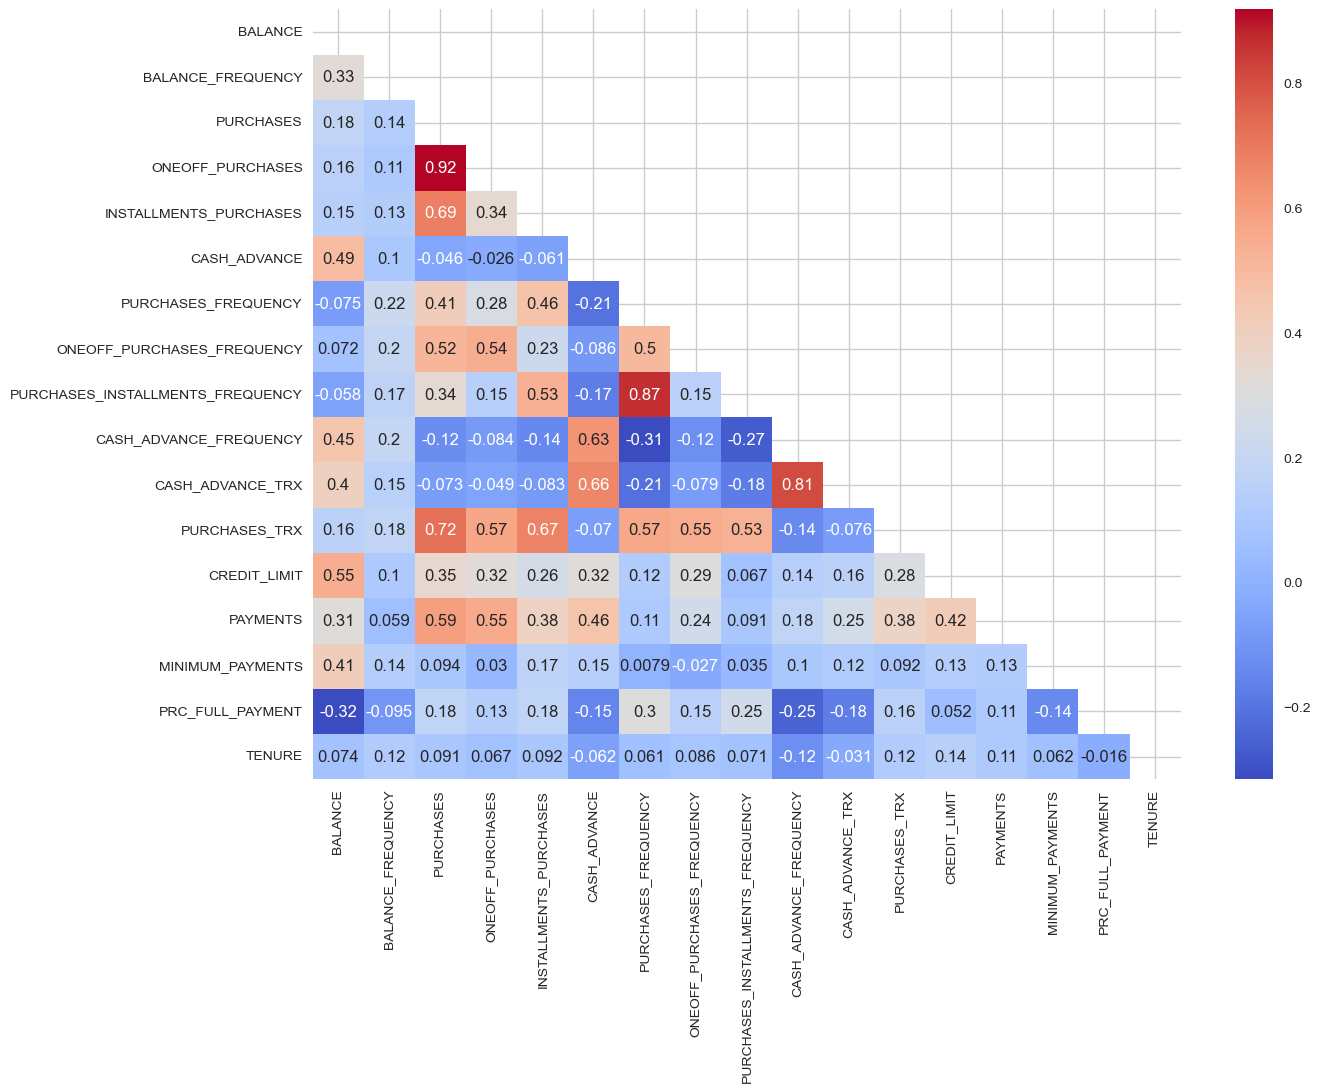

In [18]:
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(X_train.corr(), dtype=bool))
sns.heatmap(X_train.corr(), mask=mask, annot=True, cmap="coolwarm")

In [19]:
def remove_correlated_features(X_train, X_test=None, threshold=0.80):
    corr = X_train.corr(numeric_only=True).abs()

    upper = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )
    cols_drop = [col for col in upper.columns if (upper[col] >= threshold).any()]

    print(f"Variáveis removidas (corr >= {threshold}):")
    print(cols_drop)

    X_train = X_train.drop(columns=cols_drop)

    if X_test is not None:
        X_test = X_test.drop(columns=cols_drop)
        return X_train, X_test, cols_drop

    return X_train, cols_drop

X_train_cut, X_test_cut, cols_drop = remove_correlated_features(X_train, X_test, threshold=0.80)

Variáveis removidas (corr >= 0.8):
['ONEOFF_PURCHASES', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_TRX']


## Clusterização com Kmeans - Sem normalização

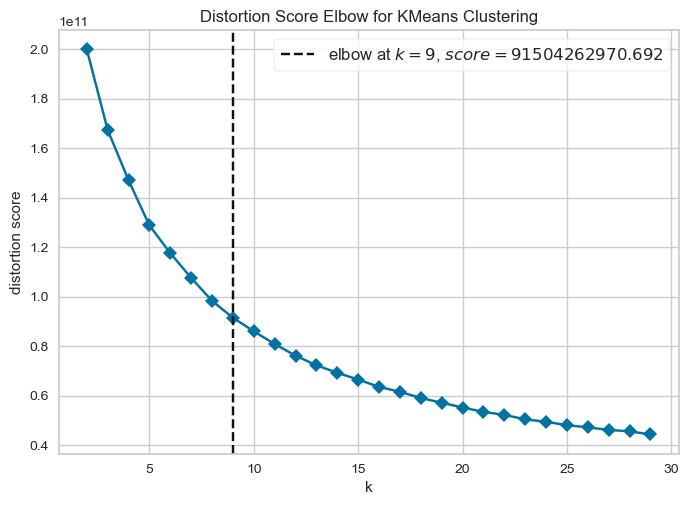

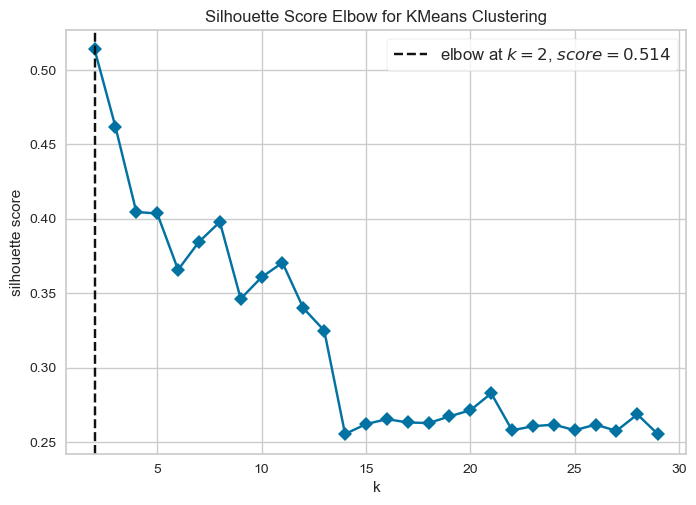

In [20]:
def get_silhoete_and_elbow(data, k_range=(2, 30)):

    model = KMeans(
        init="k-means++",
        random_state=77,
        n_init=10
    )

    elbow = KElbowVisualizer(
        model,
        k=k_range,
        metric='distortion',  # soma das distâncias quadráticas. Equv. inercia
        timings=False
    )
    elbow.fit(data)
    elbow.show()
    plt.show()

    silhouette = KElbowVisualizer(
        model,
        k=k_range,
        metric='silhouette',
        timings=False
    )
    silhouette.fit(data)
    silhouette.show()
    plt.show()


get_silhoete_and_elbow(X_train_cut)

In [21]:
model = KMeans(
        init="k-means++",
        random_state=67,
        n_init=10,
        n_clusters=2
)
model.fit(X_train_cut)
    
X_train_cut["cluster"] = model.predict(X_train_cut)
X_test_cut["cluster"] = model.predict(X_test_cut)

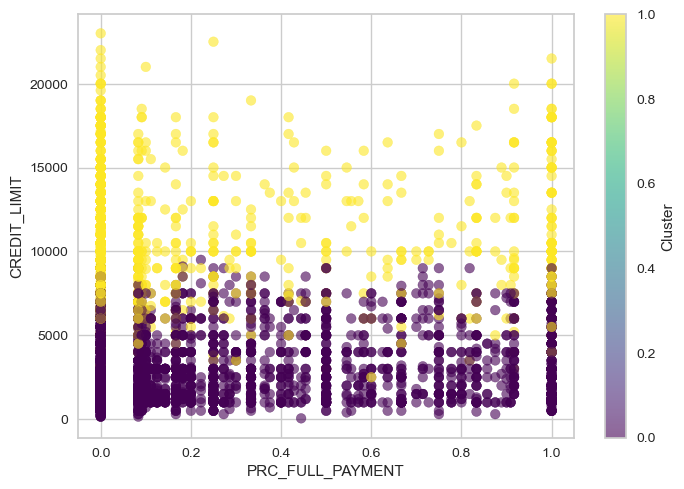

In [22]:
plt.scatter(
    X_train_cut["PRC_FULL_PAYMENT"],
    X_train_cut["CREDIT_LIMIT"],
    c=X_train_cut["cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("PRC_FULL_PAYMENT")
plt.ylabel("CREDIT_LIMIT")
plt.colorbar(label="Cluster")
plt.show()

In [23]:
def discretize_features(X_train, feature, bins, labels):
    return pd.cut(
        X_train[feature],
        bins=bins,
        include_lowest=True,
        labels=labels
    ).astype(int)

discrete_cols = pd.DataFrame()
discrete_cols["PRC_FULL_PAYMENT"] = discretize_features(
    X_train_cut,
    "PRC_FULL_PAYMENT",
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[0, 1, 2, 3, 4],
)

isso é para melhorar a visualização da tabela de contingência

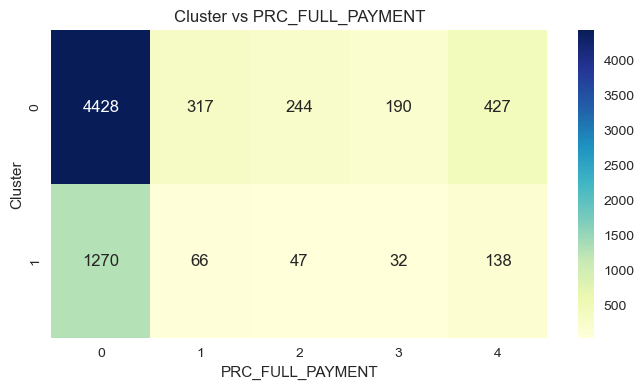

In [24]:
ct = pd.crosstab(
    X_train_cut["cluster"],
    discrete_cols["PRC_FULL_PAYMENT"]
)

def build_heatmap(ct):
    plt.figure(figsize=(8, 4))
    sns.heatmap(
        ct,
        annot=True,      
        fmt="d",        
        cmap="YlGnBu"
    )
    plt.xlabel("PRC_FULL_PAYMENT")
    plt.ylabel("Cluster")
    plt.title("Cluster vs PRC_FULL_PAYMENT")
    plt.show()
    
build_heatmap(ct)

## Clusterização com normalização

In [25]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


def compare_preprocessing_kmeans(X, k_range=(2, 30)):

    normalizers = {
        "StandardScaler": StandardScaler(),
        "RobustScaler": RobustScaler(),
        "MinMaxScaler": MinMaxScaler(),
        "Log1p": None
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    star_handles_left  = []
    star_handles_right = []

    k_values = list(range(k_range[0], k_range[1] + 1))

    for name, transformer in normalizers.items():

        if name == "Log1p":
            X_proc = np.log1p(X)
        else:
            X_proc = transformer.fit_transform(X)

        _dummy_fig, _dummy_ax = plt.subplots()
        model = KMeans(init="k-means++", random_state=77, n_init=10)
        elbow = KElbowVisualizer(
            model, k=k_range, metric="distortion",
            timings=False, ax=_dummy_ax          
        )
        elbow.fit(X_proc)
        plt.close(_dummy_fig)                    

        line = axes[0].plot(
            elbow.k_values_,
            elbow.k_scores_,
            marker="o",
            label=name
        )[0]
        color = line.get_color()

        if elbow.elbow_value_ is not None:
            idx = list(elbow.k_values_).index(elbow.elbow_value_)
            axes[0].scatter(
                elbow.elbow_value_, elbow.k_scores_[idx],
                marker="*", s=400, color=color,
                edgecolor="black", linewidth=1.5, zorder=10
            )
            star_handles_left.append(
                plt.Line2D([0], [0], marker="*", color="w",
                           markerfacecolor=color, markeredgecolor="black",
                           markersize=14, label=f"{name}  k={elbow.elbow_value_}")
            )

        sil_scores = np.array([
            silhouette_score(
                X_proc,
                KMeans(init="k-means++", n_clusters=k, random_state=77, n_init=10)
                    .fit_predict(X_proc)
            )
            for k in k_values
        ])

        line_sil  = axes[1].plot(k_values, sil_scores, marker="o", label=name)[0]
        color_sil = line_sil.get_color()

        best_idx = int(np.argmax(sil_scores))
        best_k   = k_values[best_idx]

        axes[1].scatter(
            best_k, sil_scores[best_idx],
            marker="*", s=400, color=color_sil,
            edgecolor="black", linewidth=1.5, zorder=10
        )
        star_handles_right.append(
            plt.Line2D([0], [0], marker="*", color="w",
                       markerfacecolor=color_sil, markeredgecolor="black",
                       markersize=14, label=f"{name}  k={best_k}")
        )

    axes[0].set_title("Elbow Method (Inertia)")
    axes[0].set_xlabel("Numero de Clusters (k)")
    axes[0].set_ylabel("Distortion / Inertia")
    axes[0].grid(alpha=0.3)

    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("Numero de Clusters (k)")
    axes[1].set_ylabel("Silhouette")
    axes[1].grid(alpha=0.3)

    for ax, star_handles in zip(axes, [star_handles_left, star_handles_right]):
        line_handles, _ = ax.get_legend_handles_labels()
        separator = plt.Line2D([0], [0], color="none", label="─" * 18)

        ax.legend(
            handles=line_handles + [separator] + star_handles,
            title="Pre-processamento",
            loc="upper right",
            fontsize=8,
            title_fontsize=9
        )

    plt.tight_layout()
    plt.show()

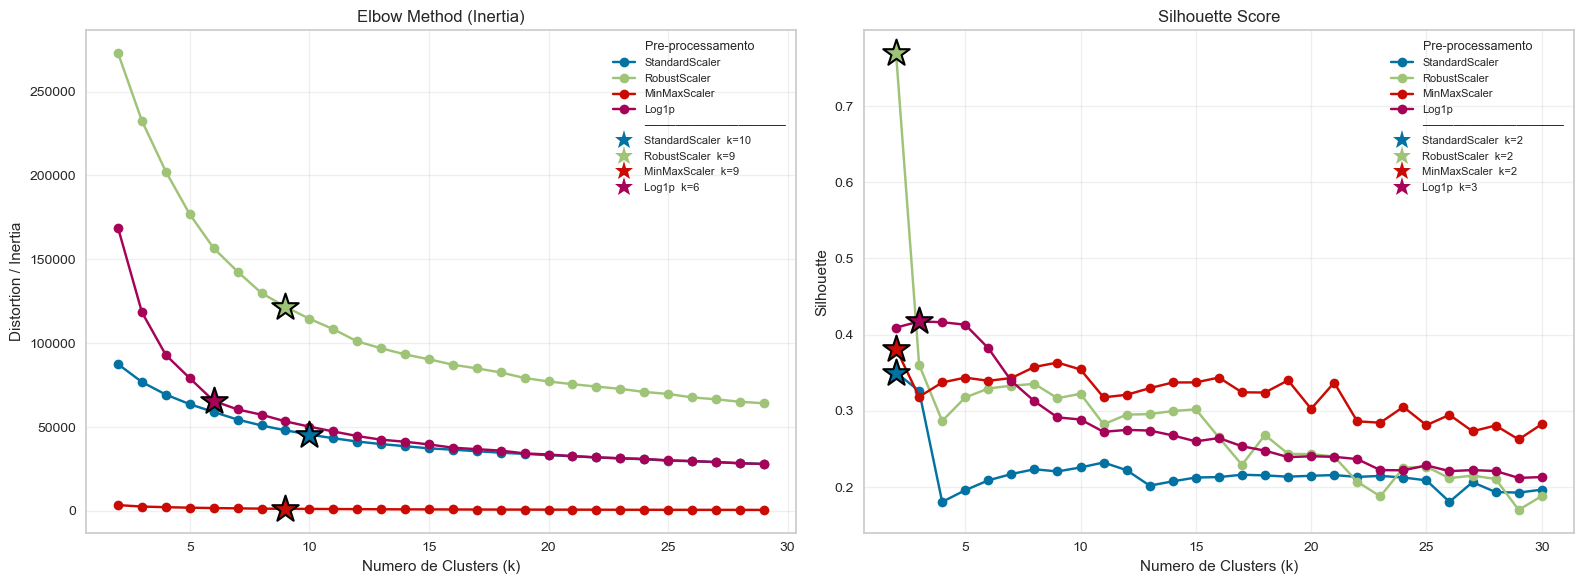

In [26]:
compare_preprocessing_kmeans(X_train_cut)

treinar os modelos com os melhores parâmetros de cada normalização e mostrar o scatter plot deles, e também a tabela de contingência. Vai ter uma complicação para escolher o melhor parâmetro, então talvez deva ser treinado mais de um modelo para cada preprocessamento

## DBSCAN sem normalização

checar se a forma de selecionar os hiperparâmetros está correta

In [27]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

def compare_dbscan_params(X):
    results = []

    for min_samples in np.arange(5, 30, 5):
        for eps in np.arange(0.01, 5, 0.1):

            db = DBSCAN(
                eps=eps,
                min_samples=min_samples
            )

            labels = db.fit_predict(X)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            if n_clusters < 2:
                continue

            score = silhouette_score(X, labels)

            results.append({
                "eps": eps,
                "min_samples": min_samples,
                "clusters": n_clusters,
                "silhouette": score
            })

    results = pd.DataFrame(results)
    if results.empty:
        print("No parameter combination produced at least 2 clusters.")
        return results
    results = results.sort_values(
        "silhouette",
        ascending=False
    )

    return results

compare_dbscan_params(X_train_cut)

No parameter combination produced at least 2 clusters.


""


não conseguiu detectar clusters. acho que nesse caso não há o que fazer

## DBSCAN com normalização

aumentar as buscas por eps e min_samples. muitas buscas fica lento demais, de acordo com esse, deixar o anterior também
```
score = silhouette_score(
                    X_transformed,
                    labels,
                    sample_size=min(1000, len(X_transformed)),
                    random_state=42
                )
```
tentar aumentar o  sample_size ou remover. coloquei isso pois calcular o silhouette_score estava demorando um absurdo

In [28]:
normalizers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "Log1p": None
}

def compare_dbscan_params_normalizations(X):
    all_results = []

    for normalizer_name, normalizer in normalizers.items():
        if normalizer is None:
            X_transformed = np.log1p(X)
        else:
            X_transformed = normalizer.fit_transform(X)

        for min_samples in [5, 10]:
            for eps in [0.5, 1.5, 3.0]:

                db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
                labels = db.fit_predict(X_transformed)

                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

                if n_clusters < 2:
                    continue

                score = silhouette_score(
                    X_transformed,
                    labels,
                    sample_size=min(1000, len(X_transformed)),
                    random_state=42
                )

                all_results.append({
                    "normalizer": normalizer_name,
                    "eps": eps,
                    "min_samples": min_samples,
                    "clusters": n_clusters,
                    "silhouette": score
                })

    results = pd.DataFrame(all_results)

    if results.empty:
        print("No parameter combination produced at least 2 clusters.")
        return results

    return results.sort_values("silhouette", ascending=False).reset_index(drop=True)

compare_dbscan_params_normalizations(X_train_cut)

,normalizer,eps,min_samples,clusters,silhouette
0,StandardScaler,3.0,5,2,0.606933
1,MinMaxScaler,0.5,5,2,0.362735
2,MinMaxScaler,0.5,10,2,0.360703
3,StandardScaler,1.5,10,2,0.231384
4,Log1p,1.5,10,10,0.194642
5,StandardScaler,1.5,5,11,0.178200
6,Log1p,1.5,5,13,0.176724
7,Log1p,3.0,10,2,0.121391
8,RobustScaler,1.5,10,6,0.092700
9,Log1p,3.0,5,3,0.073441


selecionar os melhores e fazer o scatter plot deles (para cada tipo de normalização)

## Clusterização hierarquica

In [29]:
from sklearn.cluster import AgglomerativeClustering


def compare_linkages(X, n_clusters=3):

    results = []

    for linkage in ["ward", "complete", "average", "single"]:

        metrics = ["euclidean"] if linkage == "ward" else [
            "euclidean", "manhattan", "cosine"
        ]

        for metric in metrics:

            try:
                labels = AgglomerativeClustering(
                    n_clusters=n_clusters,
                    linkage=linkage,
                    metric=metric
                ).fit_predict(X)

                results.append({
                    "linkage": linkage,
                    "metric": metric,
                    "silhouette": silhouette_score(X, labels)
                })

            except Exception:
                pass

    return pd.DataFrame(results).sort_values(
        "silhouette",
        ascending=False
    )

compare_linkages(X_train_cut, n_clusters=2)

,linkage,metric,silhouette
1,complete,euclidean,0.902075
4,average,euclidean,0.900880
7,single,euclidean,0.889208
8,single,manhattan,0.889208
5,average,manhattan,0.888362
2,complete,manhattan,0.664180
6,average,cosine,0.496063
0,ward,euclidean,0.471713
3,complete,cosine,0.157512
9,single,cosine,-0.258054


isso de cima ele não pediu, depois vejo se faço algo

tentar melhorar os gráficos e normalizar os dados antes de aplicar. acho que não precisa todas as normlizações, talvez só o RobustScaler que já teve a melhor performace antes

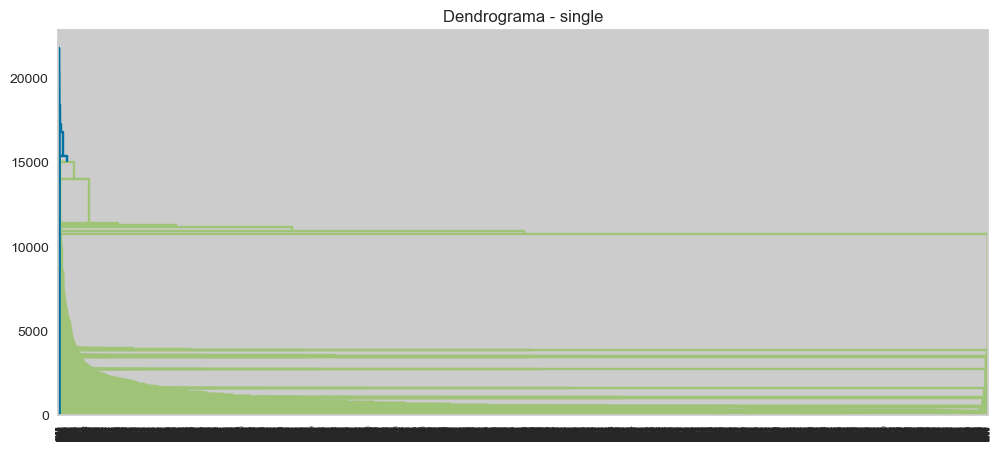

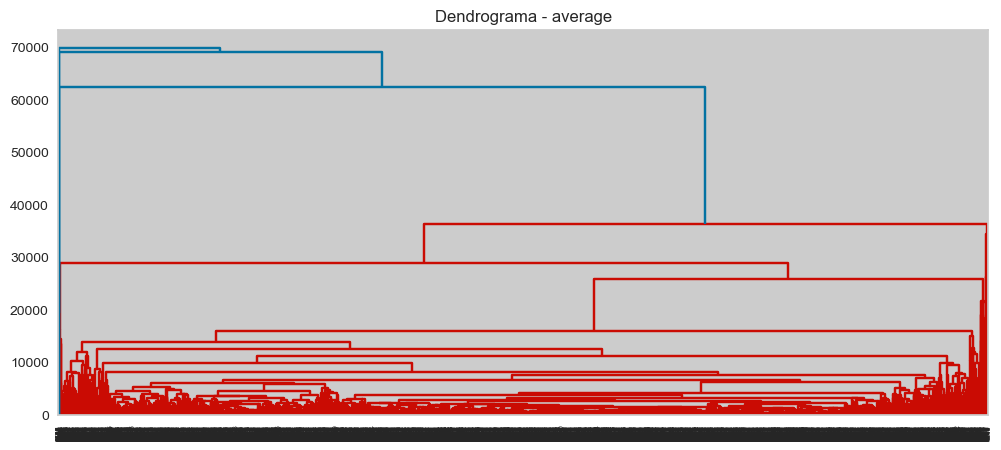

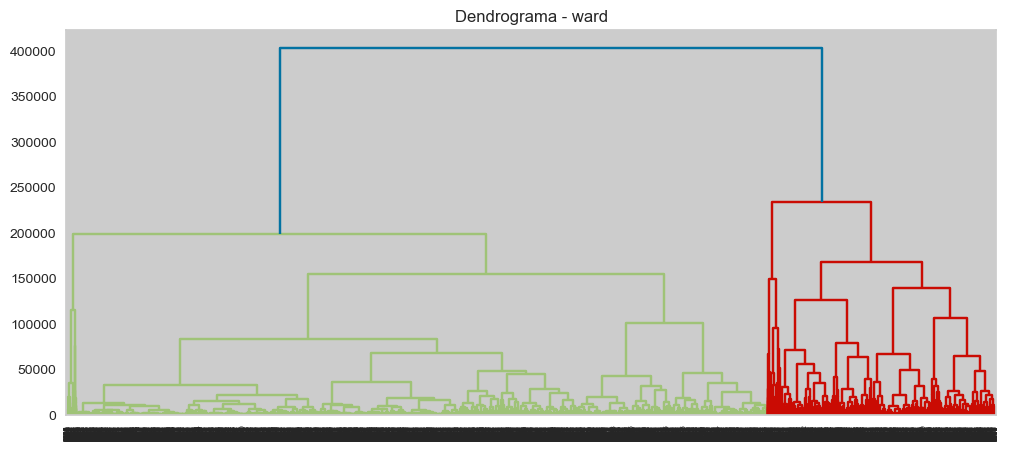

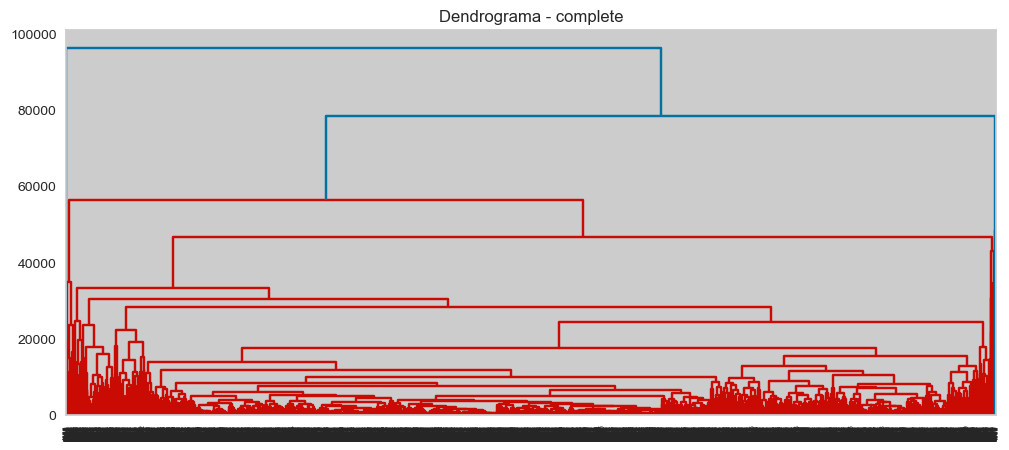

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

methods = ["single", "average", "ward", "complete"]

for metd in methods:

    Z = linkage(
        X_train_cut,
        method=metd,  
        metric="euclidean"  # Acho que não precisa variar isso
    )

    plt.figure(figsize=(12, 5))
    dendrogram(Z)
    plt.title(f"Dendrograma - {metd}")
    plt.show()

fazer cortes no eixo Y para definir o número de clusters em cada método

comparar a seleção do linkage com o kmeans normalizado (melhor). também seria legal comparar o scatter plot deles

## PCA E classificação supervisionada

usar melhor modelo de clusterização encontrado para gerar uma coluna cluster, que será a target para os modelos supervisionados.
Vamos usar KNN (precisa normalizar também é bom testar as 3 normalizações de sempre e ver a melhor) e Árvore de decisão (Não precisa de nada)

In [42]:
from mpl_toolkits.mplot3d import Axes3D


def plot_pca_3d(X, y=None, scaler=StandardScaler()):
    '''y=classe para colorir, opcional'''

    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(X_scaled)

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    if y is not None:
        scatter = ax.scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            X_pca[:, 2],
            c=y,
            alpha=0.7,
            cmap="rainbow"
        )
        plt.colorbar(scatter)
    else:
        ax.scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            X_pca[:, 2],
            alpha=0.7
        )

    var = pca.explained_variance_ratio_

    ax.set_xlabel(f"PC1 ({var[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var[1]:.1%})")
    ax.set_zlabel(f"PC3 ({var[2]:.1%})")

    ax.set_title(
        f"PCA 3D - Variância acumulada: {var[:3].sum():.1%}"
    )

    plt.tight_layout()
    plt.show()

    return X_pca, pca

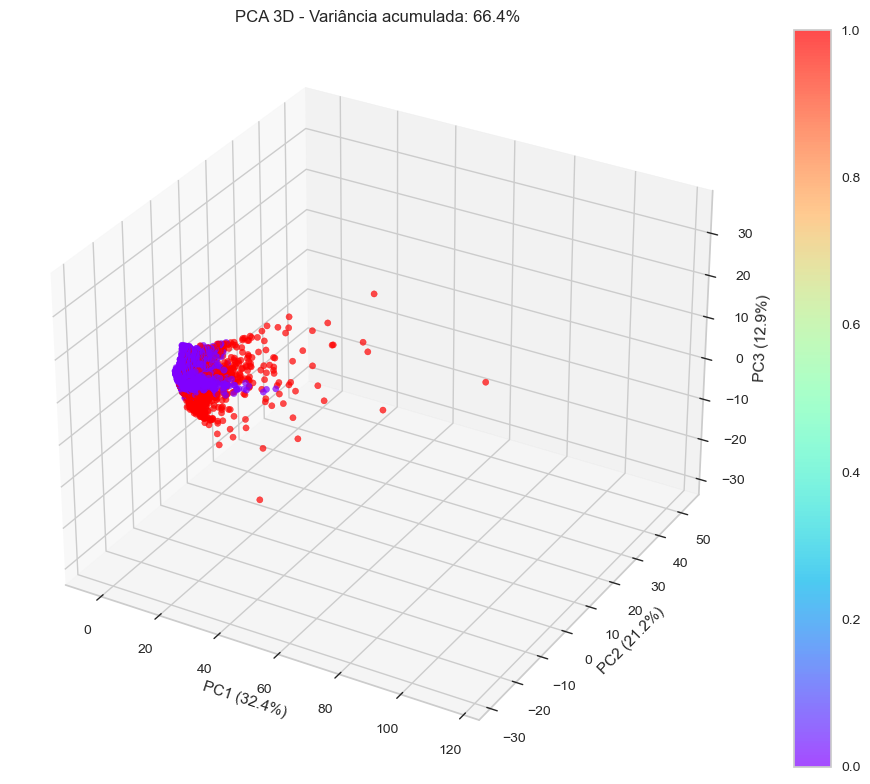

In [43]:
X_pca, pca = plot_pca_3d(X_train_cut.drop(columns=["cluster"]), y=X_train_cut["cluster"], scaler=RobustScaler())

pelo formato dos PCAs é um dataset bem compicado de custerizar mesmo

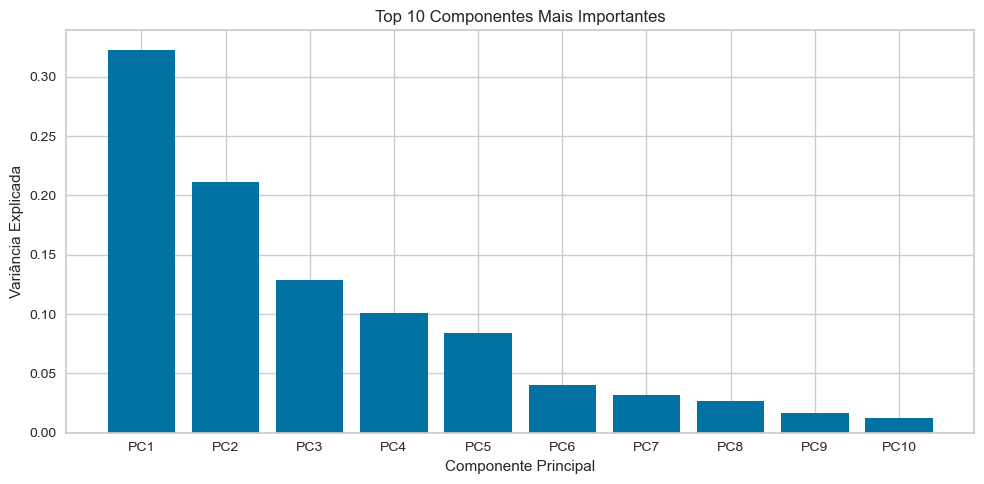

,Componente,Variancia_Explicada
0,PC1,0.322968
1,PC2,0.211393
2,PC3,0.128607
3,PC4,0.100718
4,PC5,0.083706
5,PC6,0.039894
6,PC7,0.031796
7,PC8,0.026462
8,PC9,0.016447
9,PC10,0.012477


In [31]:
def plot_top_pca_components(X, n_components=None, top_n=10):
    X_scaled = RobustScaler().fit_transform(X)

    pca = PCA(n_components=n_components)
    pca.fit(X_scaled)

    explained_var = pca.explained_variance_ratio_

    df = pd.DataFrame({
        "Componente": [f"PC{i}" for i in range(1, len(explained_var) + 1)],
        "Variancia_Explicada": explained_var
    })

    df = df.sort_values("Variancia_Explicada", ascending=False).head(top_n)

    plt.figure(figsize=(10, 5))
    plt.bar(df["Componente"], df["Variancia_Explicada"])
    plt.xlabel("Componente Principal")
    plt.ylabel("Variância Explicada")
    plt.title(f"Top {top_n} Componentes Mais Importantes")
    plt.tight_layout()
    plt.show()

    return df

plot_top_pca_components(X_train_cut, top_n=10)

acho que melhor seria usar apenas os top 5